In [1]:
%matplotlib inline

import math
import os
import re
import altair as alt
import numpy as np
import pandas as pd
import scipy.stats
import yaml
import neutcurve
import scipy.stats
print(f"Using `neutcurve` version {neutcurve.__version__}")
import sys

# allow more rows for Altair
_ = alt.data_transformers.disable_max_rows()

from pathlib import Path

# Set working directory to project root
# This ensures the path is always correct regardless of kernel state
repo_root = Path('/fh/fast/bloom_j/computational_notebooks/csimonich/2025/RSV_Long_F_DMS/RSV_Long_F_DMS/non-pipeline_analyses/validations/')
os.chdir(repo_root)
print(f"Working directory: {os.getcwd()}")



Using `neutcurve` version 2.1.0
Working directory: /fh/fast/bloom_j/computational_notebooks/csimonich/2025/RSV_Long_F_DMS/RSV_Long_F_DMS/non-pipeline_analyses/validations


In [19]:
# Load combined dataset (already filtered to plotting-relevant rows across notebooks)

# Source files used for point mutant analyses
point_source_files = [
    '250828_fractinfect.csv',
    '251002_fractinfect_molar.csv',
    '251212_fractinfect_molar.csv',
    '251217_fractinfect_molar_pointmt.csv',
    '2025.07.24_fractinfect_Nirsev_IgG_Fab_molar.csv'
]

# Viruses required for point mutant analyses (Long + B1)
point_mutant_viruses_required = {
    # Long
    '40. Long GS4',
    '40_Long GS4',
    'RSV Long F WT ',
    '38_RSV_F_Long_N67T',
    'RSV Long F K68N ',
    'RSV Long F K68Q ',
    'RSV Long F K201S ',
    'RSV Long F K201T ',
    '17_RSV_F_Long_K209D',
    '39_RSV_F_Long_K209Q',
    '14_RSV_F_Long_V207E',
    '15_RSV_F_Long_Q210T',
    '16_RSV_F_Long_S215K',
    '18_RSV_F_Long_D73N',
    '19_RSV_F_Long_P205S',
    '20_RSV_F_Long_S211R',
    '21. RSV_F_Long_R429M',
    '22_RSV_F_Long_G446D',
    '23. RSV_F_Long_S443P',
    '24. RSV_F_Long_R429S',

    # B1
    '42. B1',
    '42_B1',
    'RSV B1 F WT',
    'RSV B1 F K68N',
    'RSV B1 F K68Q',
    'RSV B1 F N201S',
    'RSV B1 F N201T',
    '28_RSV_F_B1_Q209D',
    '26_RSV_F_B1_Q210T',
    '27_RSV_F_B1_S215K',
    '29_RSV_F_B1_D73N',
    '30_RSV_F_B1_P205S',
    '31_RSV_F_B1_S211R',
    '32_RSV_F_B1_R429M',
    '33_RSV_F_B1_G446D',
    '34_RSV_F_B1_S443P',
    '35_RSV_F_B1_R429S',
    '25_RSV_F_B1_V207E',
}

# Load combined data once
combined_data = pd.read_csv('01_data/combined_frac_infect.csv')
print(f"Loaded {len(combined_data)} rows from combined_frac_infect.csv")

# -------------------------------------------------------------------
# Ensure combined data includes all point-mutant rows needed for DMS
# -------------------------------------------------------------------
raw_dir = Path('01_data/frac_infect')
key_cols = [
    'serum', 'virus', 'replicate', 'concentration', 'well_id',
    'plate_name', 'experiment_rep', 'fraction infectivity',
    'input_folder', 'source_file'
]

combined_keys = set(
    tuple(row) for row in combined_data[key_cols].astype(str).fillna('').values
)

added_rows = 0
augmented = []

for src in point_source_files:
    raw_path = raw_dir / src
    if not raw_path.exists():
        continue
    raw = pd.read_csv(raw_path)
    raw = raw[raw['virus'].isin(point_mutant_viruses_required)].copy()
    raw = raw[~raw['serum'].str.contains('Suptavumab', na=False)]
    raw['source_file'] = src

    raw_keys = raw[key_cols].astype(str).fillna('').values
    mask = [tuple(row) not in combined_keys for row in raw_keys]
    raw_add = raw[mask]
    if len(raw_add) > 0:
        augmented.append(raw_add)
        for row in raw_add[key_cols].astype(str).fillna('').values:
            combined_keys.add(tuple(row))
        added_rows += len(raw_add)

if added_rows > 0:
    combined_data = pd.concat([combined_data] + augmented, ignore_index=True)
    combined_data.to_csv('01_data/combined_frac_infect.csv', index=False)
    print(f"Updated combined_frac_infect.csv with {added_rows} missing point-mutant rows")

# Keep only rows from point mutant source files for the main dataset
combined_point = combined_data[combined_data['source_file'].isin(point_source_files)].copy()
print(f"Point mutant subset: {len(combined_point)} rows")

# Control viruses to always include (even if they don't match experiment_rep filter)
control_viruses = ['40. Long GS4', '42. B1', '40_Long GS4', '42_B1']

# Filter by experiment_rep column
# Include rows with validation AND mutant (matches both "point mutant validation" and "validation point mutants")
# OR include specific control viruses
# Exclude rows with 'Low RLU'
df = combined_point[
    (
        (combined_point['experiment_rep'].str.contains('validation', case=False, na=False) &
         combined_point['experiment_rep'].str.contains('mutant', case=False, na=False)) |
        combined_point['virus'].isin(control_viruses)
    ) &
    ~combined_point['experiment_rep'].str.contains('Low RLU', case=False, na=False)
].copy()

print(f"After experiment_rep filtering: {len(df)} rows")
print(f"  - Included: rows containing both 'validation' AND 'mutant' (case-insensitive)")
print(f"  - Included: control viruses {control_viruses}")

# Filter out Suptavumab from July data (keep existing logic)
n_before_supt = len(df)
df = df[~df['serum'].str.contains('Suptavumab', na=False)]
n_after_supt = len(df)
if n_before_supt > n_after_supt:
    print(f"Filtered out {n_before_supt - n_after_supt} Suptavumab rows")

# Fix virus name inconsistency: normalize '40 Long GS4' to '40. Long GS4'
df['virus'] = df['virus'].str.replace('40 Long GS4', '40. Long GS4', regex=False)


print(f"\nFinal dataset: {len(df)} rows")
print(f"\nUnique sera: {sorted(df['serum'].unique())}")
print(f"\nNumber of unique viruses: {len(df['virus'].unique())}")
print(f"Unique viruses: {sorted(df['virus'].unique())}")


Loaded 2516 rows from combined_frac_infect.csv
Point mutant subset: 1872 rows
After experiment_rep filtering: 1548 rows
  - Included: rows containing both 'validation' AND 'mutant' (case-insensitive)
  - Included: control viruses ['40. Long GS4', '42. B1', '40_Long GS4', '42_B1']

Final dataset: 1548 rows

Unique sera: ['Clesrovimab Fab', 'Clesrovimab IgG', 'Nirsevimab Fab', 'Nirsevimab IgG']

Number of unique viruses: 39
Unique viruses: ['14_RSV_F_Long_V207E', '15_RSV_F_Long_Q210T', '16_RSV_F_Long_S215K', '17_RSV_F_Long_K209D', '18_RSV_F_Long_D73N', '19_RSV_F_Long_P205S', '20_RSV_F_Long_S211R', '21. RSV_F_Long_R429M', '22_RSV_F_Long_G446D', '23. RSV_F_Long_S443P', '24. RSV_F_Long_R429S', '26_RSV_F_B1_Q210T', '27_RSV_F_B1_S215K', '28_RSV_F_B1_Q209D', '29_RSV_F_B1_D73N', '30_RSV_F_B1_P205S', '31_RSV_F_B1_S211R', '32_RSV_F_B1_R429M', '33_RSV_F_B1_G446D', '34_RSV_F_B1_S443P', '35_RSV_F_B1_R429S', '36_RSV_F_B1_T67N', '37_RSV_F_B1_Q209K', '38_RSV_F_Long_N67T', '39_RSV_F_Long_K209Q', '40. Lo

In [20]:
# Create neutcurve fits
fits = neutcurve.curvefits.CurveFits(
    data=df,
    fixbottom=0,
    fixtop=1,  # Set ceiling at 1.5
)

print("Fits created successfully")



Fits created successfully


In [21]:
# Legend helpers: order WT first then by site, and label WT as "wildtype"
import re

WT_LABELS = {
    '40. Long GS4', '40_Long GS4', '42. B1', '42_B1',
    'RSV Long F WT ', 'RSV B1 F WT', 'RSV Long 1', 'RSV B1 1'
}

def _is_wt_label(label):
    if label in WT_LABELS:
        return True
    label_str = str(label)
    return label_str.strip().lower().startswith('wt') or ' wt' in label_str.lower() or 'wildtype' in label_str.lower()

def _extract_site_from_label(label):
    # Standard format: ..._K209D
    match = re.search(r'\b[A-Z](\d+)[A-Z]\b', label)
    if match:
        return int(match.group(2))
    # Early format: 'RSV Long F K68N ' or any token like K68N
    match = re.search(r'[A-Z](d+)[A-Z]', label)
    if match:
        return int(match.group(1))
    return None

def apply_legend_ordering(ax):
    legend = ax.get_legend()
    if not legend:
        return

    handles, labels = ax.get_legend_handles_labels()
    items = []
    for handle, label in zip(handles, labels):
        is_wt = _is_wt_label(label)
        site = _extract_site_from_label(label)
        sort_key = (0, 0, label) if is_wt else (1, site if site is not None else 10**9, label)
        display_label = 'wildtype' if is_wt else label
        items.append((sort_key, handle, display_label))

    items.sort(key=lambda x: x[0])
    handles_sorted = [i[1] for i in items]
    labels_sorted = [i[2] for i in items]

    fontsize = legend.get_texts()[0].get_fontsize() if legend.get_texts() else None
    ax.legend(handles_sorted, labels_sorted, bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=True, fontsize=fontsize)
    new_legend = ax.get_legend()
    if new_legend:
        new_legend.get_frame().set_linewidth(0.5)




In [22]:
# Create unfiltered virus lists that include early data (250828, 251002)
# These lists include mutations at sites 67, 68, 201, and 209

print("Creating extended virus lists with combined data...")

# Long viruses with combined data (19 total)
long_viruses_with_early = [
    # Controls (2)
    '40. Long GS4',              # Regular WT control
        '40_Long GS4',             # Alternate WT control (underscore)
    'RSV Long F WT ',            # Early WT control (TRAILING SPACE!)

    # Site 67 (1 mutation from 251212)
    '38_RSV_F_Long_N67T',

    # Site 68 (2 mutations from 250828)
    'RSV Long F K68N ',          # TRAILING SPACE!
    'RSV Long F K68Q ',          # TRAILING SPACE!

    # Site 201 (2 mutations from 250828)
    'RSV Long F K201S ',         # TRAILING SPACE!
    'RSV Long F K201T ',         # TRAILING SPACE!

    # Site 209 (2 mutations from 251212)
    '17_RSV_F_Long_K209D',
    '39_RSV_F_Long_K209Q',

    # Other mutations from existing plots (10)
    '14_RSV_F_Long_V207E',
    '15_RSV_F_Long_Q210T',
    '16_RSV_F_Long_S215K',
    '18_RSV_F_Long_D73N',
    '19_RSV_F_Long_P205S',
    '20_RSV_F_Long_S211R',
    '21. RSV_F_Long_R429M',
    '22_RSV_F_Long_G446D',
    '23. RSV_F_Long_S443P',
    '24. RSV_F_Long_R429S',
]

# B1 viruses with combined data (18 total)
b1_viruses_with_early = [
    # Controls (2)
    '42. B1',                    # Regular WT control
        '42_B1',                   # Alternate WT control (underscore)
    'RSV B1 F WT',               # Early WT control (no trailing space)

    # Site 68 (2 mutations from 251002)
    'RSV B1 F K68N',
    'RSV B1 F K68Q',

    # Site 201 (2 mutations from 251002)
    'RSV B1 F N201S',
    'RSV B1 F N201T',

    # Site 209 (1 mutation from 251212 - EXCLUDE Q209K)
    '28_RSV_F_B1_Q209D',

    # Other mutations from existing plots (11)
    '26_RSV_F_B1_Q210T',
    '27_RSV_F_B1_S215K',
    '29_RSV_F_B1_D73N',
    '30_RSV_F_B1_P205S',
    '31_RSV_F_B1_S211R',
    '32_RSV_F_B1_R429M',
    '33_RSV_F_B1_G446D',
    '34_RSV_F_B1_S443P',
    '35_RSV_F_B1_R429S',
    '25_RSV_F_B1_V207E',
]

print(f"✓ Long viruses with combined data: {len(long_viruses_with_early)} total")
print("  - Controls: 2 (regular + early WT)")
print("  - Site 67: 1 mutation (N67T)")
print("  - Site 68: 2 mutations (K68N, K68Q)")
print("  - Site 201: 2 mutations (K201S, K201T)")
print("  - Site 209: 2 mutations (K209D, K209Q)")
print("  - Other sites: 10 mutations")

print(f"\n✓ B1 viruses with combined data: {len(b1_viruses_with_early)} total")
print("  - Controls: 2 (regular + early WT)")
print("  - Site 68: 2 mutations (K68N, K68Q)")
print("  - Site 201: 2 mutations (N201S, N201T)")
print("  - Site 209: 1 mutation (Q209D)")
print("  - Other sites: 11 mutations")
print("  - EXCLUDED: B1 N67T and B1 Q209K (revert to Long WT)")




Creating extended virus lists with combined data...
✓ Long viruses with combined data: 20 total
  - Controls: 2 (regular + early WT)
  - Site 67: 1 mutation (N67T)
  - Site 68: 2 mutations (K68N, K68Q)
  - Site 201: 2 mutations (K201S, K201T)
  - Site 209: 2 mutations (K209D, K209Q)
  - Other sites: 10 mutations

✓ B1 viruses with combined data: 18 total
  - Controls: 2 (regular + early WT)
  - Site 68: 2 mutations (K68N, K68Q)
  - Site 201: 2 mutations (N201S, N201T)
  - Site 209: 1 mutation (Q209D)
  - Other sites: 11 mutations
  - EXCLUDED: B1 N67T and B1 Q209K (revert to Long WT)


In [23]:
# ======================
# Master color mapping function (shared across notebooks)
# ======================
def get_master_color_mapping():
    """
    Master color mapping matching reference notebook colors for shared mutations.
    Reference: point_mutant_validations_1212and1217-Copy1.ipynb

    Colors preserve the exact assignments from reference notebook for all shared mutations.
    New mutations receive distinct colors.
    """
    color_mapping = {
        # From reference notebook (13 mutations) - PRESERVE EXACT COLORS
        '73N': '#1f77b4',    # blue
        '205S': '#ff7f0e',   # orange
        '207E': '#2ca02c',   # green
        '209D': '#d62728',   # red
        '209Q': '#17becf',   # aqua/cyan
        '210T': '#9467bd',   # purple
        '211R': '#8c564b',   # brown
        '215K': '#e377c2',   # pink
        '67T': '#bcbd22',    # yellow-green/olive
        '429M': '#bcbd22',   # yellow-green/olive (same as 67T)
        '446D': '#ff7f0e',   # orange (same as 205S)
        '443P': '#1f77b4',   # blue (same as 73N)
        '429S': '#2ca02c',   # green (same as 207E)

        # New mutations (5 mutations only in target notebooks) - ASSIGN DISTINCT COLORS
        '68N': '#FF1493',    # deep pink/magenta
        '68Q': '#4B0082',    # indigo (dark purple)
        '201S': '#008B8B',   # dark cyan/teal
        '201T': '#32CD32',   # lime green
        '67N': '#9932CC',    # dark orchid
    }
    return color_mapping


# Create extended color-marker mapping function for viruses with early data
# Handles both early format ('RSV Long F K68N ') and standard format ('17_RSV_F_Long_K209D')

import re

def create_extended_colorscheme(virus_list, background_type, master_colors):
    """
    Create color and marker mappings for extended virus lists including early data.
    Handles two naming formats:
    - Early: 'RSV Long F K68N ' (with trailing spaces)
    - Later: '17_RSV_F_Long_K209D' (standard format)

    Args:
        virus_list: List of virus names
        background_type: 'Long' or 'B1'
        master_colors: Master color mapping from get_master_color_mapping()

    Returns:
        Dictionary mapping virus names to (color, marker) tuples
    """
    # Define early WT controls
    early_wt_controls = {
        'Long': 'RSV Long F WT ',  # TRAILING SPACE!
        'B1': 'RSV B1 F WT'        # No trailing space
    }

    # Define regular WT controls
    regular_wt_controls = {
        'Long': '40. Long GS4',
        'B1': '42. B1'
    }

    # WT control colors
    wt_colors = {'Long': '#000000', 'B1': '#000000'}  # Black, Grey

    # Mutant markers
    mutant_markers = {'Long': 's', 'B1': '^'}  # Square, Triangle

    virus_to_color_marker = {}

    for virus in virus_list:
        # Check if regular WT control
        if virus in regular_wt_controls[background_type]:
            virus_to_color_marker[virus] = (wt_colors[background_type], 'o')  # Circle

        # Check if early WT control
        elif virus == early_wt_controls[background_type]:
            virus_to_color_marker[virus] = (wt_colors[background_type], 'D')  # Diamond

        # Handle early virus format (e.g., 'RSV Long F K68N ')
        elif virus.startswith(('RSV Long F', 'RSV B1 F')):
            # Extract mutation: look for pattern like 'K68N' or 'N201T'
            # Format: 'RSV Long F K68N ' -> K68N
            parts = virus.strip().split()
            if len(parts) >= 4:
                mutation_str = parts[3]  # e.g., 'K68N', 'N201T'
                # Extract position and new residue: K68N -> 68N
                match = re.match(r'[A-Z](\d+)([A-Z])$', mutation_str)
                if match:
                    position = match.group(1)
                    new_residue = match.group(2)
                    mut_key = f"{position}{new_residue}"
                    color = master_colors.get(mut_key, '#999999')
                    marker = mutant_markers[background_type]
                    virus_to_color_marker[virus] = (color, marker)

        # Handle standard format (e.g., '17_RSV_F_Long_K209D')
        else:
            match = re.search(r'_([A-Z])(\d+)([A-Z])$', virus)
            if match:
                position = match.group(2)
                new_residue = match.group(3)
                mut_key = f"{position}{new_residue}"
                color = master_colors.get(mut_key, '#999999')
                marker = mutant_markers[background_type]
                virus_to_color_marker[virus] = (color, marker)

    return virus_to_color_marker

# Get master color mapping
master_colors = get_master_color_mapping()

# Create extended mappings for both backgrounds
print("Creating extended color-marker mappings...")
long_virus_to_color_marker_extended = create_extended_colorscheme(
    long_viruses_with_early, 'Long', master_colors
)
b1_virus_to_color_marker_extended = create_extended_colorscheme(
    b1_viruses_with_early, 'B1', master_colors
)

print(f"✓ Long extended mapping: {len(long_virus_to_color_marker_extended)} viruses")
print(f"✓ B1 extended mapping: {len(b1_virus_to_color_marker_extended)} viruses")

# Verify early WT controls have diamond markers
for bg, controls in [('Long', 'RSV Long F WT '), ('B1', 'RSV B1 F WT')]:
    mapping = long_virus_to_color_marker_extended if bg == 'Long' else b1_virus_to_color_marker_extended
    if controls in mapping:
        color, marker = mapping[controls]
        print(f"  {bg} early WT: color={color}, marker={marker} {'✓' if marker == 'D' else '✗'}")




Creating extended color-marker mappings...
✓ Long extended mapping: 19 viruses
✓ B1 extended mapping: 17 viruses
  Long early WT: color=#000000, marker=D ✓
  B1 early WT: color=#000000, marker=D ✓


In [24]:
# Define virus lists for point mutant plots
# Organize by background strain: Long (subtype A) and B1 (subtype B)

# Long background controls (for Long mutant plots)
long_controls = [
    '40. Long GS4'
]

# B1 background controls (for B1 mutant plots)
b1_controls = [
   '42. B1'
]

# Long background point mutants (subtype A)
# Note: Dec 12 data uses underscore (e.g., '20_RSV_F_Long_S211R')
#       Dec 17 data uses period with space (e.g., '21. RSV_F_Long_R429M')
long_mutants = [
    '14_RSV_F_Long_V207E',
    '15_RSV_F_Long_Q210T',
    '16_RSV_F_Long_S215K',
    '17_RSV_F_Long_K209D',
    '18_RSV_F_Long_D73N',
    '19_RSV_F_Long_P205S',
    '20_RSV_F_Long_S211R',
    '21. RSV_F_Long_R429M',  # Dec 17 format (period + space)
    '22_RSV_F_Long_G446D',
    '23. RSV_F_Long_S443P',  # Dec 17 format (period + space)
    '24. RSV_F_Long_R429S',  # Dec 17 format (period + space)
]

# B1 background point mutants (subtype B)
b1_mutants = [
    '26_RSV_F_B1_Q210T',
    '27_RSV_F_B1_S215K',
    '28_RSV_F_B1_Q209D',
    '29_RSV_F_B1_D73N',
    '30_RSV_F_B1_P205S',
    '31_RSV_F_B1_S211R',
    '32_RSV_F_B1_R429M',
    '33_RSV_F_B1_G446D',
    '34_RSV_F_B1_S443P',
    '35_RSV_F_B1_R429S',
]

# Combined lists for plotting
long_viruses = long_controls + long_mutants
b1_viruses = b1_controls + b1_mutants
all_point_mutants = long_mutants + b1_mutants

print(f"Long background:")
print(f"  - Controls: {len(long_controls)}")
print(f"  - Point mutants: {len(long_mutants)}")
print(f"  - Total: {len(long_viruses)}")
print(f"\nB1 background:")
print(f"  - Controls: {len(b1_controls)}")
print(f"  - Point mutants: {len(b1_mutants)}")
print(f"  - Total: {len(b1_viruses)}")
print(f"\nTotal point mutants: {len(all_point_mutants)}")

Long background:
  - Controls: 1
  - Point mutants: 11
  - Total: 12

B1 background:
  - Controls: 1
  - Point mutants: 10
  - Total: 11

Total point mutants: 21


In [25]:
# Create standardized color scheme across backgrounds
# Same mutations get the same COLOR, but different MARKERS for Long vs B1


def create_standardized_colorscheme(long_virus_list, b1_virus_list):
    # Create a standardized color scheme using systematic color assignments.
    # Same mutations get the same COLOR across backgrounds, different MARKERS.
    import re

    master_colors = get_master_color_mapping()

    long_color_marker = {}
    b1_color_marker = {}

    # Control colors
    long_control_color = '#000000'  # Black
    b1_control_color = '#4d4d4d'    # Dark grey

    # Control markers
    long_control_marker = 'o'
    b1_control_marker = 'o'

    # Mutant markers
    long_mutant_marker = 's'
    b1_mutant_marker = '^'

    # Long background mapping
    for virus in long_virus_list:
        if virus in long_controls:
            long_color_marker[virus] = (long_control_color, long_control_marker)
        else:
            match = re.search(r'_([A-Z])(\d+)([A-Z])$', virus)
            if not match:
                match = re.search(r'([A-Z])(\d+)([A-Z])', virus)
            if match:
                position = match.group(2)
                new_residue = match.group(3)
                mut_key = f"{position}{new_residue}"
                color = master_colors.get(mut_key, '#999999')
                long_color_marker[virus] = (color, long_mutant_marker)

    # B1 background mapping
    for virus in b1_virus_list:
        if virus in b1_controls:
            b1_color_marker[virus] = (b1_control_color, b1_control_marker)
        else:
            match = re.search(r'_([A-Z])(\d+)([A-Z])$', virus)
            if not match:
                match = re.search(r'([A-Z])(\d+)([A-Z])', virus)
            if match:
                position = match.group(2)
                new_residue = match.group(3)
                mut_key = f"{position}{new_residue}"
                color = master_colors.get(mut_key, '#999999')
                b1_color_marker[virus] = (color, b1_mutant_marker)

    return long_color_marker, b1_color_marker


# Simplified controls for plotting (Dec 17 only)
long_controls_simple = ['40. Long GS4']
b1_controls_simple = ['42. B1']

long_viruses_simple = long_controls_simple + long_mutants
b1_viruses_simple = b1_controls_simple + b1_mutants

# Identify viruses with early data (250828/251002) to exclude from plots
viruses_with_early_data = set(
    df[df['source_file'].isin(['250828_fractinfect.csv', '251002_fractinfect_molar.csv'])]['virus'].unique()
)

# Create filtered virus lists for plotting (exclude early data viruses)
long_controls_for_plotting = [v for v in long_controls_simple if v not in viruses_with_early_data]
b1_controls_for_plotting = [v for v in b1_controls_simple if v not in viruses_with_early_data]
long_mutants_for_plotting = [v for v in long_mutants if v not in viruses_with_early_data]
b1_mutants_for_plotting = [v for v in b1_mutants if v not in viruses_with_early_data]

long_viruses_for_plotting = long_controls_for_plotting + long_mutants_for_plotting
b1_viruses_for_plotting = b1_controls_for_plotting + b1_mutants_for_plotting

print("Filtered virus lists for plotting:")
print(f"  Long background: {len(long_controls_for_plotting)} controls + {len(long_mutants_for_plotting)} mutants = {len(long_viruses_for_plotting)} total")
print(f"  B1 background: {len(b1_controls_for_plotting)} controls + {len(b1_mutants_for_plotting)} mutants = {len(b1_viruses_for_plotting)} total")

# Create standardized color mappings
long_virus_to_color_marker_std, b1_virus_to_color_marker_std = create_standardized_colorscheme(
    long_viruses_for_plotting, b1_viruses_for_plotting
)


Filtered virus lists for plotting:
  Long background: 1 controls + 11 mutants = 12 total
  B1 background: 1 controls + 10 mutants = 11 total


Generating Nirsevimab plots with combined data...
Settings:
  - Antibody: Nirsevimab only
  - Formats: IgG, Fab
  - Backgrounds: Long, B1
  - Includes mutations from 250828 and 251002 experiments
  - WT controls limited to 40_Long GS4 and 42_B1

  Plotting Nirsevimab IgG Long background (14 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


    Saved: 03_output/plots/point_mut_Nirsevimab_IgG_Long.pdf
  Plotting Nirsevimab IgG B1 background (11 viruses)
    Saved: 03_output/plots/point_mut_Nirsevimab_IgG_B1.pdf
  Plotting Nirsevimab Fab Long background (14 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


    Saved: 03_output/plots/point_mut_Nirsevimab_Fab_Long.pdf
  Plotting Nirsevimab Fab B1 background (11 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


    Saved: 03_output/plots/point_mut_Nirsevimab_Fab_B1.pdf

✓ Completed Nirsevimab plots with combined data
  - 4 plots generated (IgG and Fab x Long and B1)
  - Includes mutations at sites 67, 68, 201, 209
  - WT controls limited to 40_Long GS4 and 42_B1
  - All strokes set to 0.5pt


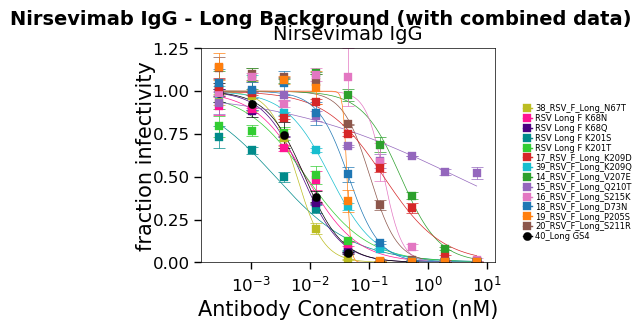

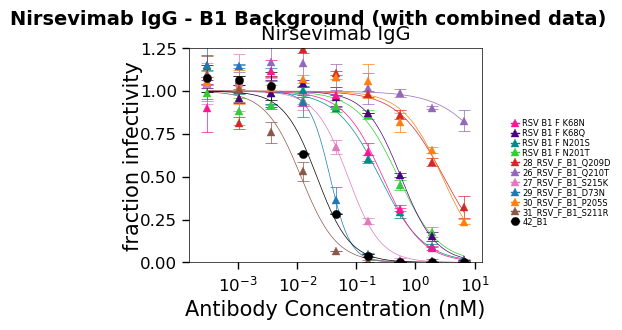

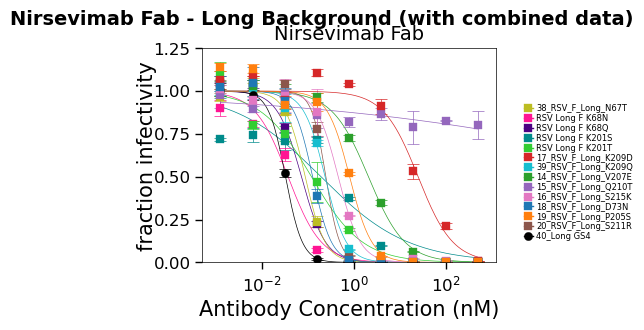

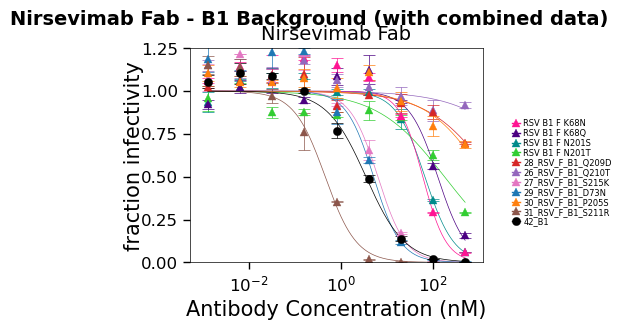

In [26]:
# Generate Nirsevimab plots with combined data included

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Store original rcParams to restore later
original_rcParams_extended = mpl.rcParams.copy()

# Set matplotlib parameters for publication-ready figures
mpl.rcParams['svg.fonttype'] = 'none'  # Make text editable in SVG
mpl.rcParams['axes.linewidth'] = 0.5   # Box around plot
mpl.rcParams['xtick.major.width'] = 0.5  # X-axis tick width
mpl.rcParams['ytick.major.width'] = 0.5  # Y-axis tick width
mpl.rcParams['xtick.minor.width'] = 0.5  # X-axis minor tick width
mpl.rcParams['ytick.minor.width'] = 0.5  # Y-axis minor tick width
mpl.rcParams['lines.linewidth'] = 0.5    # Line width for curves
mpl.rcParams['lines.markersize'] = 4
mpl.rcParams['lines.markeredgecolor'] = 'auto'  # No marker stroke
mpl.rcParams['legend.edgecolor'] = 'none'  # No legend box stroke
mpl.rcParams['lines.markeredgewidth'] = 0.25  # No stroke around markers
     # Marker size

print("Generating Nirsevimab plots with combined data...")
print("Settings:")
print("  - Antibody: Nirsevimab only")
print("  - Formats: IgG, Fab")
print("  - Backgrounds: Long, B1")
print("  - Includes mutations from 250828 and 251002 experiments")
print("  - WT controls limited to 40_Long GS4 and 42_B1\n")

# Only generate plots for Nirsevimab (not Clesrovimab)
antibodies = ['Nirsevimab']
formats = ['IgG', 'Fab']

# Use extended virus lists and mappings
background_types_extended = [
    ('Long', long_viruses_with_early, long_virus_to_color_marker_extended),
    ('B1', b1_viruses_with_early, b1_virus_to_color_marker_extended)
]

allowed_wt = {
    'Long': {'40_Long GS4'},
    'B1': {'42_B1'}
}

exclude_wt = {
    '40. Long GS4', 'RSV Long F WT ', 'RSV Long 1', 'RSV Long 2',
    '42. B1', 'RSV B1 F WT', 'RSV B1 1', 'RSV B1 2'
}

for antibody in antibodies:
    for fmt in formats:
        serum_name = f"{antibody} {fmt}"

        # Get viruses that have data for this serum
        serum_viruses = set(df[df['serum'] == serum_name]['virus'].unique())

        for background_label, virus_list, color_marker_dict in background_types_extended:
            # Filter to only viruses that have data for this serum
            viruses_to_plot = [v for v in virus_list if v in serum_viruses]

            # Keep only the main WT controls for each background
            viruses_to_plot = [
                v for v in viruses_to_plot
                if (v not in exclude_wt) or (v in allowed_wt.get(background_label, set()))
            ]

            # Also filter the color-marker mapping to match
            color_marker_dict = {k: v for k, v in color_marker_dict.items() if k in viruses_to_plot}


            # Force WT colors to black for these plots (Long + B1)
            wt_black = {'40. Long GS4', '40_Long GS4', 'RSV Long F WT ',
                        '42. B1', '42_B1', 'RSV B1 F WT'}
            for v in list(color_marker_dict.keys()):
                if v in wt_black:
                    color_marker_dict[v] = ('#000000', color_marker_dict[v][1])
            # Ensure every virus_to_plot has a color/marker (fallbacks for WT)
            missing = set(viruses_to_plot) - set(color_marker_dict.keys())
            for v in missing:
                if v in {'40. Long GS4', '40_Long GS4'}:
                    color_marker_dict[v] = ('#000000', 'o')
                elif v in {'42. B1', '42_B1'}:
                    color_marker_dict[v] = ('#000000', 'o')

            if len(viruses_to_plot) == 0:
                print(f"  Skipping {antibody} {fmt} {background_label} background (no data)")
                continue

            print(f"  Plotting {antibody} {fmt} {background_label} background ({len(viruses_to_plot)} viruses)")

            # Create the plot with increased max_viruses_per_subplot for more viruses
            fig, axes = fits.plotSera(
                xlabel='Antibody Concentration (nM)',
                sera=[serum_name],
                viruses=viruses_to_plot,
                virus_to_color_marker=color_marker_dict,
                max_viruses_per_subplot=25,  # Increased from 20 to accommodate more viruses
                ncol=2,
                draw_in_bounds=True,
                legendfontsize=6  # Slightly smaller for more items
            )

            # Apply formatting to all axes
            if isinstance(axes, np.ndarray):
                axes_list = axes.flat
            else:
                axes_list = [axes]

            for ax in axes_list:
                # Set y-axis limits
                ax.set_ylim(0, 1.25)

                # Set error bar cap width to 0.5pt
                for line in ax.lines:
                    line.set_linewidth(0.5)
                    if line.get_marker() in ['_', '|']:
                        line.set_markeredgewidth(0.5)
                # Set error bar properties
                for collection in ax.collections:
                    collection.set_linewidth(0.5)

                # Reorder legend (WT first, then by site) and relabel WT as "wildtype"
                apply_legend_ordering(ax)

            fig.suptitle(
                f"{antibody} {fmt} - {background_label} Background (with combined data)",
                y=1.001,
                fontsize=14,
                fontweight='bold'
            )

            # Save as PDF
            filename_pdf = f"03_output/plots/point_mut_{antibody}_{fmt}_{background_label}.pdf"
            fig.savefig(filename_pdf, dpi=300, bbox_inches='tight')
            print(f"    Saved: {filename_pdf}")

            # Save as SVG with editable text
            filename_svg = f'03_output/plots/point_mut_{antibody}_{fmt}_{background_label}.svg'
            fig.savefig(filename_svg, format='svg', bbox_inches='tight')
            
            fig.show()

# Restore original rcParams
mpl.rcParams.update(original_rcParams_extended)

print("\n✓ Completed Nirsevimab plots with combined data")
print("  - 4 plots generated (IgG and Fab x Long and B1)")
print("  - Includes mutations at sites 67, 68, 201, 209")
print("  - WT controls limited to 40_Long GS4 and 42_B1")
print("  - All strokes set to 0.5pt")



Generating Clesrovimab plots with combined data...
Settings:
  - Antibody: Clesrovimab only
  - Formats: IgG, Fab
  - Backgrounds: Long, B1
  - Includes mutations from 250828 and 251002 experiments
  - WT controls limited to 40_Long GS4 and 42_B1
Clesrovimab rows in df: 432
Clesrovimab viruses: ['21. RSV_F_Long_R429M', '22_RSV_F_Long_G446D', '23. RSV_F_Long_S443P', '24. RSV_F_Long_R429S', '32_RSV_F_B1_R429M', '33_RSV_F_B1_G446D', '34_RSV_F_B1_S443P', '35_RSV_F_B1_R429S', '40. Long GS4', '40_Long GS4', '42. B1', '42_B1']
  Plotting Clesrovimab IgG Long background (5 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(


  Plotting Clesrovimab IgG B1 background (5 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


  Plotting Clesrovimab Fab Long background (5 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(


  Plotting Clesrovimab Fab B1 background (5 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)



✓ Completed Clesrovimab plots with combined data
  - 4 plots generated (IgG and Fab x Long and B1)


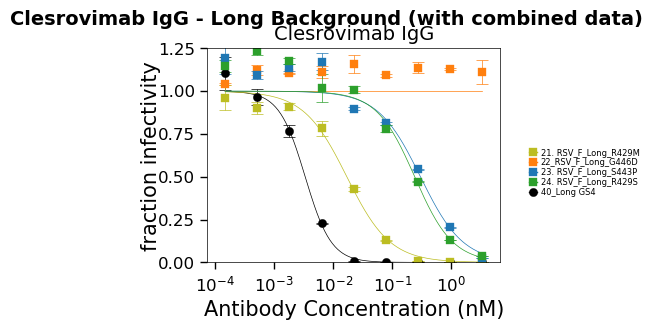

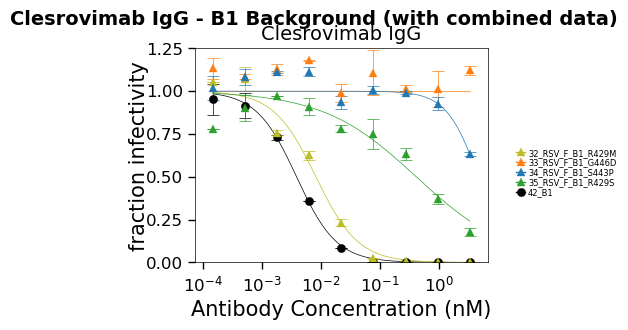

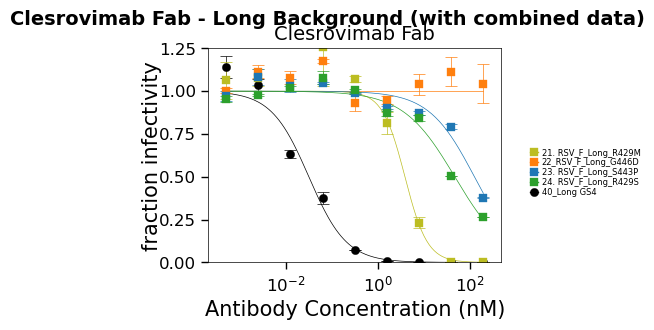

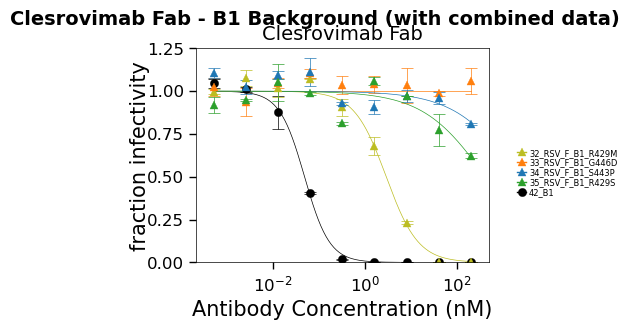

In [27]:
# Generate Clesrovimab plots with combined data included
# Uses same formatting and WT rules as Nirsevimab block above

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np


# Store original rcParams to restore later
original_rcParams_cles = mpl.rcParams.copy()

# Set matplotlib parameters for publication-ready figures
mpl.rcParams['svg.fonttype'] = 'none'  # Make text editable in SVG
mpl.rcParams['axes.linewidth'] = 0.5   # Box around plot
mpl.rcParams['xtick.major.width'] = 0.5  # X-axis tick width
mpl.rcParams['ytick.major.width'] = 0.5  # Y-axis tick width
mpl.rcParams['xtick.minor.width'] = 0.5  # X-axis minor tick width
mpl.rcParams['ytick.minor.width'] = 0.5  # Y-axis minor tick width
mpl.rcParams['lines.linewidth'] = 0.5    # Line width for curves
mpl.rcParams['lines.markersize'] = 4
mpl.rcParams['lines.markeredgecolor'] = 'auto'  # No marker stroke
mpl.rcParams['legend.edgecolor'] = 'none'  # No legend box stroke
mpl.rcParams['lines.markeredgewidth'] = 0.25  # No stroke around markers
print("Generating Clesrovimab plots with combined data...")
print("Settings:")
print("  - Antibody: Clesrovimab only")
print("  - Formats: IgG, Fab")
print("  - Backgrounds: Long, B1")
print("  - Includes mutations from 250828 and 251002 experiments")
print("  - WT controls limited to 40_Long GS4 and 42_B1")

# Subset to Clesrovimab only for plotting
df_cles = df[df['serum'].str.contains('Clesrovimab', na=False)].copy()
print(f"Clesrovimab rows in df: {len(df_cles)}")
print(f"Clesrovimab viruses: {sorted(df_cles['virus'].unique())}")

# Create fits for Clesrovimab subset
fits_cles = neutcurve.curvefits.CurveFits(
    data=df_cles,
    fixbottom=0,
    fixtop=1,
)

# Only generate plots for Clesrovimab
antibodies = ['Clesrovimab']
formats = ['IgG', 'Fab']

# Reuse the extended virus lists and mappings from the Nirsevimab block
background_types_extended = [
    ('Long', long_viruses_with_early, long_virus_to_color_marker_extended),
    ('B1', b1_viruses_with_early, b1_virus_to_color_marker_extended)
]

for antibody in antibodies:
    for fmt in formats:
        serum_name = f"{antibody} {fmt}"

        # Get viruses that have data for this serum
        serum_viruses = set(df[df['serum'] == serum_name]['virus'].unique())

        for background_label, virus_list, color_marker_dict in background_types_extended:
            # Filter to only viruses that have data for this serum
            viruses_to_plot = [v for v in virus_list if v in serum_viruses]

            # Keep only the main WT controls for each background
            viruses_to_plot = [
                v for v in viruses_to_plot
                if (v not in exclude_wt) or (v in allowed_wt.get(background_label, set()))
            ]

            # Also filter the color-marker mapping to match
            color_marker_dict = {k: v for k, v in color_marker_dict.items() if k in viruses_to_plot}


            # Force WT colors to black for these plots (Long + B1)
            wt_black = {'40. Long GS4', '40_Long GS4', 'RSV Long F WT ',
                        '42. B1', '42_B1', 'RSV B1 F WT'}
            for v in list(color_marker_dict.keys()):
                if v in wt_black:
                    color_marker_dict[v] = ('#000000', color_marker_dict[v][1])
            # Ensure every virus_to_plot has a color/marker (fallbacks for WT)
            missing = set(viruses_to_plot) - set(color_marker_dict.keys())
            for v in missing:
                if v in {'40. Long GS4', '40_Long GS4'}:
                    color_marker_dict[v] = ('#000000', 'o')
                elif v in {'42. B1', '42_B1'}:
                    color_marker_dict[v] = ('#000000', 'o')

            if len(viruses_to_plot) == 0:
                print(f"  Skipping {antibody} {fmt} {background_label} background (no data)")
                continue

            print(f"  Plotting {antibody} {fmt} {background_label} background ({len(viruses_to_plot)} viruses)")

            fig, axes = fits_cles.plotSera(
                xlabel='Antibody Concentration (nM)',
                sera=[serum_name],
                viruses=viruses_to_plot,
                virus_to_color_marker=color_marker_dict,
                max_viruses_per_subplot=25,
                ncol=2,
                draw_in_bounds=True,
                legendfontsize=6
            )

            # Apply formatting to all axes
            if isinstance(axes, np.ndarray):
                axes_list = axes.flat
            else:
                axes_list = [axes]

            for ax in axes_list:
                ax.set_ylim(0, 1.25)

                for line in ax.lines:
                    line.set_linewidth(0.5)
                    if line.get_marker() in ['_', '|']:
                        line.set_markeredgewidth(0.5)
                for collection in ax.collections:
                    collection.set_linewidth(0.5)

                apply_legend_ordering(ax)

            fig.suptitle(
                f"{antibody} {fmt} - {background_label} Background (with combined data)",
                y=1.001,
                fontsize=14,
                fontweight='bold'
            )

            filename_pdf = f"03_output/plots/point_mut_{antibody}_{fmt}_{background_label}.pdf"
            fig.savefig(filename_pdf, dpi=300, bbox_inches='tight')

            filename_svg = f'03_output/plots/point_mut_{antibody}_{fmt}_{background_label}.svg'
            fig.savefig(filename_svg, format='svg', bbox_inches='tight')

            fig.show()

print("\n✓ Completed Clesrovimab plots with combined data")
print("  - 4 plots generated (IgG and Fab x Long and B1)")

# Restore original rcParams
mpl.rcParams.update(original_rcParams_cles)


In [28]:
# Get the fit parameters table
# NOTE: This includes ALL viruses (including those excluded from plots)
params = fits.fitParams(ics=[50, 99])

# Save to CSV with updated filename reflecting combined data from all 5 files
params.to_csv("03_output/point_mut_combined_fit_params_IC50_IC99_molar.csv", index=False)

print(f"Saved fit parameters for {len(params)} serum-virus combinations")
print(f"  - Includes ALL viruses (even those excluded from plots)")
print(f"  - Includes data from all 5 files: 250828, 251002, 251212, 251217, July 2025")
print(f"Output file: 03_output/point_mut_combined_fit_params_IC50_IC99_molar.csv")
display(params.head(20))



Saved fit parameters for 86 serum-virus combinations
  - Includes ALL viruses (even those excluded from plots)
  - Includes data from all 5 files: 250828, 251002, 251212, 251217, July 2025
Output file: 03_output/point_mut_combined_fit_params_IC50_IC99_molar.csv


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters co

,serum,virus,replicate,nreplicates,ic50,ic50_bound,ic50_str,ic99,ic99_bound,ic99_str,midpoint,midpoint_bound,midpoint_bound_type,slope,top,bottom,r2,rmsd
0,Nirsevimab IgG,RSV Long F K201S,average,2,0.002617,interpolated,0.00262,2.920722,interpolated,2.92,0.002617,0.002617,interpolated,0.654787,1.0,0.0,0.973481,0.046722
1,Nirsevimab IgG,RSV Long F K68Q,average,2,0.007483,interpolated,0.00748,0.240381,interpolated,0.24,0.007483,0.007483,interpolated,1.324388,1.0,0.0,0.996815,0.022574
2,Nirsevimab IgG,RSV Long F K68N,average,2,0.008582,interpolated,0.00858,0.806105,interpolated,0.806,0.008582,0.008582,interpolated,1.011584,1.0,0.0,0.987942,0.041335
3,Nirsevimab IgG,RSV Long F K201T,average,2,0.008669,interpolated,0.00867,2.170479,interpolated,2.17,0.008669,0.008669,interpolated,0.832013,1.0,0.0,0.947715,0.079513
4,Nirsevimab IgG,RSV B1 F N201S,average,2,0.247804,interpolated,0.248,6.667000,lower,>6.67,0.247804,0.247804,interpolated,1.180762,1.0,0.0,0.990398,0.040101
5,Nirsevimab IgG,RSV B1 F N201T,average,2,0.508346,interpolated,0.508,6.667000,lower,>6.67,0.508346,0.508346,interpolated,1.259042,1.0,0.0,0.975616,0.054549
6,Nirsevimab IgG,RSV B1 F K68Q,average,2,0.567340,interpolated,0.567,6.667000,lower,>6.67,0.567340,0.567340,interpolated,1.474307,1.0,0.0,0.995224,0.026120
7,Nirsevimab IgG,RSV B1 F K68N,average,2,0.279042,interpolated,0.279,6.667000,lower,>6.67,0.279042,0.279042,interpolated,1.309586,1.0,0.0,0.977604,0.060296
8,Nirsevimab IgG,20_RSV_F_Long_S211R,average,2,0.104525,interpolated,0.105,1.173961,interpolated,1.17,0.104525,0.104525,interpolated,1.899823,1.0,0.0,0.980415,0.068091
9,Nirsevimab IgG,26_RSV_F_B1_Q210T,average,2,6.667000,lower,>6.67,6.667000,lower,>6.67,31.902606,6.667000,lower,0.962935,1.0,0.0,0.264920,0.091497


In [29]:
# Calculate fold-change relative to Long and B1 reference strains
# WITH DATE-MATCHED WT CONTROLS when available

params_clean = params.copy()

# Build mapping of source_file → available WT controls
wt_registry = {
    '250828_fractinfect.csv': {'Long': 'RSV Long F WT ', 'B1': 'RSV B1 F WT'},
    '251002_fractinfect_molar.csv': {'Long': 'RSV Long F WT ', 'B1': 'RSV B1 F WT'},
    '251212_fractinfect_molar.csv': {'Long': '40_Long GS4', 'B1': '42_B1'},
    '251217_fractinfect_molar_pointmt.csv': {'Long': '40. Long GS4', 'B1': '42. B1'},
    '2025.07.24_fractinfect_Nirsev_IgG_Fab_molar.csv': {
        'Long': 'RSV Long 1',  # Use first replicate as default
        'B1': 'RSV B1 1'
    }
}

# Global fallback references
global_refs = {'Long': '40. Long GS4', 'B1': '42. B1'}

# Create virus → source_file mapping from df
virus_to_source = df.groupby('virus')['source_file'].first().to_dict()

print("Date-matched fold change calculation:")
print(f"  WT registry covers {len(wt_registry)} source files")
print(f"  Global fallbacks: Long='{global_refs['Long']}', B1='{global_refs['B1']}'")

# Create a dataframe for fold-change calculations
fc_data = []

for serum in params_clean['serum'].unique():
    serum_data = params_clean[params_clean['serum'] == serum]
    
    # Calculate fold-changes for each virus
    for _, row in serum_data.iterrows():
        virus = row['virus']
        ic50 = row['ic50']
        
        # Determine source file for this virus
        virus_source = virus_to_source.get(virus)
        
        # Get same-date WT if available, otherwise use global
        long_ref = wt_registry.get(virus_source, {}).get('Long') or global_refs['Long']
        b1_ref = wt_registry.get(virus_source, {}).get('B1') or global_refs['B1']
        
        # Check if same-date WT was used
        date_matched_long = (virus_source in wt_registry and 'Long' in wt_registry[virus_source])
        date_matched_b1 = (virus_source in wt_registry and 'B1' in wt_registry[virus_source])
        
        # Get IC50 values for the selected reference strains
        long_ref_ic50 = serum_data[serum_data['virus'] == long_ref]['ic50'].values
        long_ref_ic50 = long_ref_ic50[0] if len(long_ref_ic50) > 0 else None
        
        b1_ref_ic50 = serum_data[serum_data['virus'] == b1_ref]['ic50'].values
        b1_ref_ic50 = b1_ref_ic50[0] if len(b1_ref_ic50) > 0 else None
        
        # Calculate fold-changes
        fc_vs_long = (ic50 / long_ref_ic50) if (long_ref_ic50 is not None and long_ref_ic50 > 0) else None
        fc_vs_b1 = (ic50 / b1_ref_ic50) if (b1_ref_ic50 is not None and b1_ref_ic50 > 0) else None
        
        fc_entry = {
            'serum': serum,
            'virus': virus,
            'ic50': ic50,
            'ic50_str': row['ic50_str'],
            'ic99': row['ic99'],
            'ic99_str': row['ic99_str'],
            'reference_long': long_ref,
            'reference_b1': b1_ref,
            'wt_control_used_long': long_ref,
            'wt_control_used_b1': b1_ref,
            'date_matched_long': date_matched_long,
            'date_matched_b1': date_matched_b1,
            'fc_vs_Long': fc_vs_long,
            'fc_vs_B1': fc_vs_b1
        }
        
        fc_data.append(fc_entry)

fc_df = pd.DataFrame(fc_data)

# Save to CSV with updated filename
fc_df.to_csv('03_output/point_mut_combined_fold_changes_vs_Long_B1.csv', index=False)

print(f"\nCalculated fold-changes for {len(fc_df)} serum-virus combinations")

# Summary statistics
n_date_matched_long = fc_df['date_matched_long'].sum()
n_date_matched_b1 = fc_df['date_matched_b1'].sum()
print(f"\nDate-matching statistics:")
print(f"  - Long background: {n_date_matched_long}/{len(fc_df)} ({100*n_date_matched_long/len(fc_df):.1f}%) used same-date WT")
print(f"  - B1 background: {n_date_matched_b1}/{len(fc_df)} ({100*n_date_matched_b1/len(fc_df):.1f}%) used same-date WT")

print(f"\nWT controls used:")
print(f"  Long references: {sorted(fc_df['wt_control_used_long'].unique())}")
print(f"  B1 references: {sorted(fc_df['wt_control_used_b1'].unique())}")

print(f"\nSaved to: 03_output/point_mut_combined_fold_changes_vs_Long_B1.csv")
display(fc_df.head(20))



Date-matched fold change calculation:
  WT registry covers 5 source files
  Global fallbacks: Long='40. Long GS4', B1='42. B1'

Calculated fold-changes for 86 serum-virus combinations

Date-matching statistics:
  - Long background: 86/86 (100.0%) used same-date WT
  - B1 background: 86/86 (100.0%) used same-date WT

WT controls used:
  Long references: ['40. Long GS4', '40_Long GS4', 'RSV Long F WT ']
  B1 references: ['42. B1', '42_B1', 'RSV B1 F WT']

Saved to: 03_output/point_mut_combined_fold_changes_vs_Long_B1.csv


,serum,virus,ic50,ic50_str,ic99,ic99_str,reference_long,reference_b1,wt_control_used_long,wt_control_used_b1,date_matched_long,date_matched_b1,fc_vs_Long,fc_vs_B1
0,Nirsevimab IgG,RSV Long F K201S,0.002617,0.00262,2.920722,2.92,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,0.606946,0.148790
1,Nirsevimab IgG,RSV Long F K68Q,0.007483,0.00748,0.240381,0.24,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,1.735751,0.425512
2,Nirsevimab IgG,RSV Long F K68N,0.008582,0.00858,0.806105,0.806,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,1.990814,0.488040
3,Nirsevimab IgG,RSV Long F K201T,0.008669,0.00867,2.170479,2.17,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,2.011009,0.492990
4,Nirsevimab IgG,RSV B1 F N201S,0.247804,0.248,6.667000,>6.67,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,57.481705,14.091398
5,Nirsevimab IgG,RSV B1 F N201T,0.508346,0.508,6.667000,>6.67,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,117.918436,28.907209
6,Nirsevimab IgG,RSV B1 F K68Q,0.567340,0.567,6.667000,>6.67,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,131.602903,32.261898
7,Nirsevimab IgG,RSV B1 F K68N,0.279042,0.279,6.667000,>6.67,RSV Long F WT,RSV B1 F WT,RSV Long F WT,RSV B1 F WT,True,True,64.727941,15.867783
8,Nirsevimab IgG,20_RSV_F_Long_S211R,0.104525,0.105,1.173961,1.17,40_Long GS4,42_B1,40_Long GS4,42_B1,True,True,12.692051,4.861960
9,Nirsevimab IgG,26_RSV_F_B1_Q210T,6.667000,>6.67,6.667000,>6.67,40_Long GS4,42_B1,40_Long GS4,42_B1,True,True,809.544792,310.113319


In [30]:
# Save fold-change data to second filename (for compatibility)
fc_df.to_csv('03_output/point_mut_combined_fold_changes_vs_references.csv', index=False)
print(f"Fold-change data also saved to: 03_output/point_mut_combined_fold_changes_vs_references.csv")



Fold-change data also saved to: 03_output/point_mut_combined_fold_changes_vs_references.csv


Preparing cross-background comparison plots for positions 67 and 209...
Loaded 720 rows from Dec 12 data (251212)
Unique sera: ['Nirsevimab Fab', 'Nirsevimab IgG']
Unique viruses: ['14_RSV_F_Long_V207E', '15_RSV_F_Long_Q210T', '16_RSV_F_Long_S215K', '17_RSV_F_Long_K209D', '18_RSV_F_Long_D73N', '19_RSV_F_Long_P205S', '20_RSV_F_Long_S211R', '25_RSV_F_B1_V207E', '26_RSV_F_B1_Q210T', '27_RSV_F_B1_S215K', '28_RSV_F_B1_Q209D', '29_RSV_F_B1_D73N', '30_RSV_F_B1_P205S', '31_RSV_F_B1_S211R', '36_RSV_F_B1_T67N', '37_RSV_F_B1_Q209K', '38_RSV_F_Long_N67T', '39_RSV_F_Long_K209Q', '40_Long GS4', '42_B1']
Created neutcurve fits from Dec 12 data

Virus lists:
  67T/67N: ['40_Long GS4', '42_B1', '38_RSV_F_Long_N67T', '36_RSV_F_B1_T67N']
  209Q/209K: ['40_Long GS4', '42_B1', '39_RSV_F_Long_K209Q', '37_RSV_F_B1_Q209K']

✓ Created color schemes for cross-background plots
  Position 67: Yellow-green shades with distinct markers
  Position 209: Aqua shades with distinct markers

Generating cross-background c

/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


  Plotting position 209 - IgG and Fab combined


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)



✓ Completed cross-background comparison plots
  - 2 plots generated: 67T/67N and 209Q/209K (IgG + Fab combined)
  - Saved as both SVG and PDF


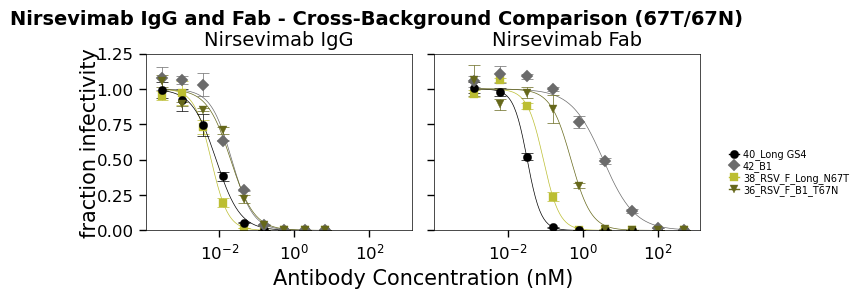

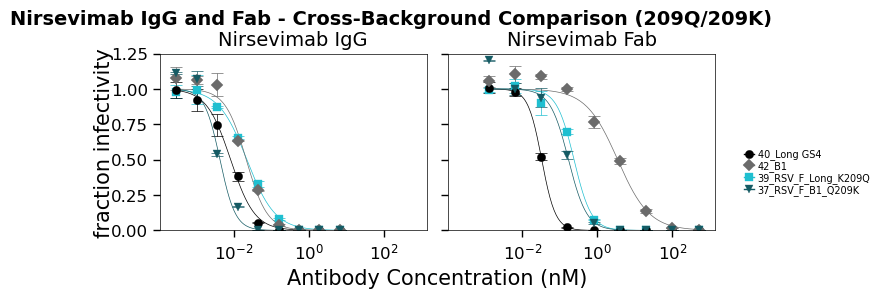

In [31]:
# Generate comparison plots for 67T/67N and 209Q/209K mutations
# Shows Long and B1 backgrounds on same plot for direct comparison

import matplotlib.pyplot as plt
import matplotlib as mpl
import re

print("Preparing cross-background comparison plots for positions 67 and 209...")

# Get Dec 12 data directly from combined_data (before global exclusions were applied)
# This allows us to include '37_RSV_F_B1_Q209K' which is in the exclude_viruses list
df_dec12 = combined_data[
    combined_data['source_file'] == '251212_fractinfect_molar.csv'
].copy()

# Filter for Nirsevimab only (IgG and Fab)
df_dec12_nirs = df_dec12[df_dec12['serum'].str.contains('Nirsevimab', na=False)]

print(f"Loaded {len(df_dec12_nirs)} rows from Dec 12 data (251212)")
print(f"Unique sera: {sorted(df_dec12_nirs['serum'].unique())}")
print(f"Unique viruses: {sorted(df_dec12_nirs['virus'].unique())}")

# Create neutcurve fits from this unfiltered Dec 12 data
fits_dec12 = neutcurve.curvefits.CurveFits(
    data=df_dec12_nirs,
    fixbottom=0,
    fixtop=1,
)

print("Created neutcurve fits from Dec 12 data")

# Define virus lists for cross-background comparison
# Each list includes: Long WT, B1 WT, Long mutant, B1 mutant

# 67T/67N comparison
viruses_67 = ['40_Long GS4', '42_B1', '38_RSV_F_Long_N67T', '36_RSV_F_B1_T67N']

# 209Q/209K comparison
viruses_209 = ['40_Long GS4', '42_B1', '39_RSV_F_Long_K209Q', '37_RSV_F_B1_Q209K']

print(f"\nVirus lists:")
print(f"  67T/67N: {viruses_67}")
print(f"  209Q/209K: {viruses_209}")


# Helper function to extract mutation code from virus name
def extract_mutation(virus):
    """Extract mutation code (e.g., '67T', '209K') from virus name."""
    # Pattern: underscore + WT amino acid + position + mutant amino acid at end
    match = re.search(r'_([A-Z])(\d+)([A-Z])$', virus)
    if match:
        wt_aa, position, mut_aa = match.groups()
        return f"{position}{mut_aa}"
    return None

# Create color scheme function for cross-background plots
def create_cross_background_colorscheme(virus_list, mutation_colors_markers):
    """
    Create color scheme for cross-background comparison.
    
    Args:
        virus_list: List of viruses to plot
        mutation_colors_markers: Dict mapping mutation codes to (color, long_marker, b1_marker)
    
    Returns:
        Dict mapping virus names to (color, marker) tuples
    """
    color_marker = {}
    
    for virus in virus_list:
        if '40_Long GS4' in virus or '40. Long GS4' in virus:
            color_marker[virus] = ('#000000', 'o')  # Black circle for Long WT
        elif '42_B1' in virus or '42. B1' in virus:
            color_marker[virus] = ('#6b6b6b', 'D')  # Slightly lighter grey + distinct marker for B1 WT
        elif 'Long' in virus:
            # Long mutant - use color and Long marker from mutation_colors_markers
            mutation_key = extract_mutation(virus)
            if mutation_key in mutation_colors_markers:
                color, long_marker, _ = mutation_colors_markers[mutation_key]
                color_marker[virus] = (color, long_marker)
        else:
            # B1 mutant - use color and B1 marker from mutation_colors_markers
            mutation_key = extract_mutation(virus)
            if mutation_key in mutation_colors_markers:
                color, _, b1_marker = mutation_colors_markers[mutation_key]
                color_marker[virus] = (color, b1_marker)
    
    return color_marker

# Define mutation colors and markers
# Mutations at same site get shades of same color, different markers
mutation_colors_markers_67 = {
    '67T': ('#bcbe32', 's', '^'),   #square (Long), triangle (B1)
    '67N': ('#66681B', 'D', 'v'),  #diamond (Long), inverted triangle (B1)
}

mutation_colors_markers_209 = {
    '209Q': ('#1fbfd0', 's', '^'),  #  square (Long), triangle (B1)
    '209K': ('#155B64', 'D', 'v'),  # diamond (Long), inverted triangle (B1)
}

# Create color schemes for each mutation pair
colors_67 = create_cross_background_colorscheme(viruses_67, mutation_colors_markers_67)
colors_209 = create_cross_background_colorscheme(viruses_209, mutation_colors_markers_209)

print(f"\n✓ Created color schemes for cross-background plots")
print(f"  Position 67: Yellow-green shades with distinct markers")
print(f"  Position 209: Aqua shades with distinct markers")

# Store original rcParams to restore later
original_rcParams = mpl.rcParams.copy()

# Set matplotlib parameters for publication-ready figures
mpl.rcParams['svg.fonttype'] = 'none'  # Make text editable in SVG
mpl.rcParams['axes.linewidth'] = 0.5   # Box around plot
mpl.rcParams['xtick.major.width'] = 0.5  # X-axis tick width
mpl.rcParams['ytick.major.width'] = 0.5  # Y-axis tick width
mpl.rcParams['xtick.minor.width'] = 0.5  # X-axis minor tick width
mpl.rcParams['ytick.minor.width'] = 0.5  # Y-axis minor tick width
mpl.rcParams['lines.linewidth'] = 0.5    # Line width for curves
mpl.rcParams['lines.markersize'] = 4
mpl.rcParams['lines.markeredgecolor'] = 'auto'  # No marker stroke
mpl.rcParams['legend.edgecolor'] = 'none'  # No legend box stroke
mpl.rcParams['lines.markeredgewidth'] = 0.25  # No stroke around markers
     # Marker size

print("\nGenerating cross-background comparison plots...")
print("Settings:")
print("  - SVG text: editable")
print("  - Line width: 0.5pt")
print("  - Error bar width: 0.5pt")
print("  - Axes/ticks width: 0.5pt")

# Generate combined IgG + Fab plots (side-by-side) for both mutation pairs
sera = ['Nirsevimab IgG', 'Nirsevimab Fab']
mutation_pairs = [
    ('67', viruses_67, colors_67, '67T/67N'),
    ('209', viruses_209, colors_209, '209Q/209K')
]

for position, virus_list, color_scheme, label in mutation_pairs:
    print(f"  Plotting position {position} - IgG and Fab combined")

    fig, axes = fits_dec12.plotSera(
        xlabel='Antibody Concentration (nM)',
        sera=sera,
        viruses=virus_list,
        virus_to_color_marker=color_scheme,
        max_viruses_per_subplot=20,
        ncol=2,
        draw_in_bounds=True,
        legendfontsize=7
    )

    # Apply formatting to all axes
    if isinstance(axes, np.ndarray):
        axes_list = axes.flat
    else:
        axes_list = [axes]

    for ax in axes_list:
        # Set y-axis limits
        ax.set_ylim(0, 1.25)

        # Set error bar cap width to 0.5pt
        for line in ax.lines:
            line.set_linewidth(0.5)
            if line.get_marker() in ['_', '|']:
                line.set_markeredgewidth(0.5)
        # Set error bar properties
        for collection in ax.collections:
            collection.set_linewidth(0.5)

        # Reposition legend
        apply_legend_ordering(ax)

    fig.suptitle(f'Nirsevimab IgG and Fab - Cross-Background Comparison ({label})',
                 y=1.001, fontsize=14, fontweight='bold')

    # Save as SVG with editable text
    filename_svg = f'03_output/plots/cross_background_{position}_Nirsevimab_IgG_Fab.svg'
    fig.savefig(filename_svg, format='svg', bbox_inches='tight')

    # Also save as PDF
    filename_pdf = f'03_output/plots/cross_background_{position}_Nirsevimab_IgG_Fab.pdf'
    fig.savefig(filename_pdf, dpi=300, bbox_inches='tight')

    fig.show()

# Restore original rcParams
mpl.rcParams.update(original_rcParams)

print("\n✓ Completed cross-background comparison plots")
print("  - 2 plots generated: 67T/67N and 209Q/209K (IgG + Fab combined)")
print("  - Saved as both SVG and PDF")


Saved: 03_output/plots/Neut_IgG_Fab_nM_byAb_Long_B1_A2020_B2024.svg


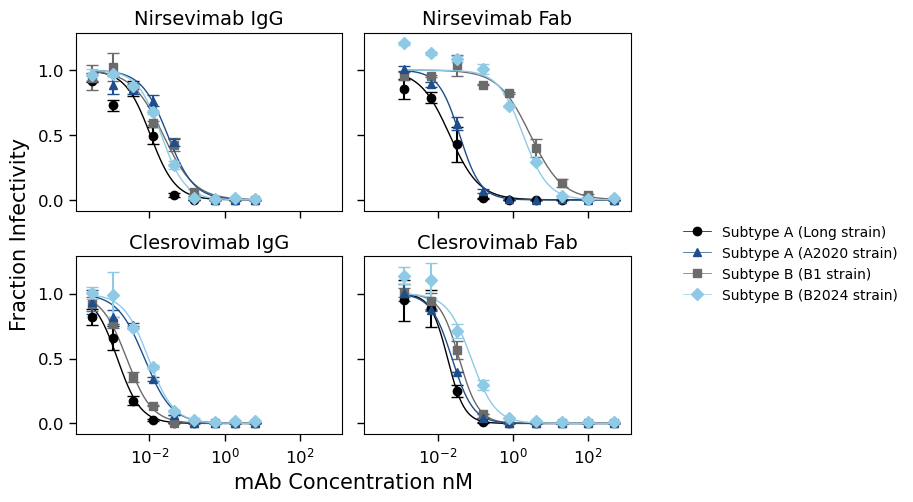

In [32]:
# July 24 (Nirsevimab IgG/Fab) — Plot by sera, Long/B1/A2020/B2024 with consistent colors
# Uses combined_frac_infect.csv but restricts to the July 24 source file

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np


# Load July 24 subset (exclude Suptavumab if present)
df_july24 = combined_data[combined_data['source_file'] == '2025.07.24_fractinfect_Nirsev_IgG_Fab_molar.csv'].copy()
df_july24 = df_july24[~df_july24['serum'].str.contains('Suptavumab', na=False)]

# Plot by sera, Long/B1/A2020/B2024 with consistent colors
viruses_lb_ab = sorted([v for v in df_july24['virus'].unique() if any(k in v for k in ['Long', 'B1', 'A2020', 'B2024'])])

# Assign consistent colors and markers by background
marker_map = {
    'Long': 'o',    # circles
    'B1': 's',      # squares
    'A2020': '^',   # triangles
    'B2024': 'D',   # diamonds
}
virus_to_color_marker = {}
for v in viruses_lb_ab:
    if 'Long' in v:
        color = '#000000'
        marker = marker_map['Long']
    elif 'B1' in v:
        color = '#6b6b6b'
        marker = marker_map['B1']
    elif 'A2020' in v:
        color = '#1f4e8c'  # dark blue
        marker = marker_map['A2020']
    else:
        color = '#8ecae6'  # light blue for B2024
        marker = marker_map['B2024']
    virus_to_color_marker[v] = (color, marker)

fits_july24 = neutcurve.curvefits.CurveFits(
    data=df_july24,
    fixbottom=0,
    fixtop=1,
)

fig,axes = fits_july24.plotSera(
            xlabel='mAb Concentration nM', max_viruses_per_subplot=4,
            viruses=viruses_lb_ab,
            virus_to_color_marker=virus_to_color_marker,
            draw_in_bounds=True, ncol=2,
            ylabel='Fraction Infectivity'
,
            legendfontsize=7
)

if isinstance(axes, np.ndarray):
    axes_list = axes.flat
else:
    axes_list = [axes]

# Remove per-axis legends before creating figure-level legend
for ax in axes_list:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
label_map = {}
for v in viruses_lb_ab:
    if 'Long' in v:
        label_map[v] = 'Subtype A (Long strain)'
    elif 'A2020' in v:
        label_map[v] = 'Subtype A (A2020 strain)'
    elif 'B1' in v:
        label_map[v] = 'Subtype B (B1 strain)'
    elif 'B2024' in v:
        label_map[v] = 'Subtype B (B2024 strain)'
    else:
        label_map[v] = v


# Build a figure-level legend with standardized subtype labels
legend_order = [
    'Subtype A (Long strain)',
    'Subtype A (A2020 strain)',
    'Subtype B (B1 strain)',
    'Subtype B (B2024 strain)',
]
legend_handles = []
legend_labels = []
for label in legend_order:
    # find any virus that maps to this label
    virus = next((v for v, l in label_map.items() if l == label), None)
    if virus and virus in virus_to_color_marker:
        color, marker = virus_to_color_marker[virus]
        legend_handles.append(plt.Line2D([0], [0], color=color, marker=marker, linestyle='-', linewidth=0.5))
        legend_labels.append(label)
if legend_handles:
    fig.legend(legend_handles, legend_labels, bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=False)
fig.savefig('03_output/plots/Neut_IgG_Fab_nM_byAb_Long_B1_A2020_B2024.svg', bbox_inches='tight')

print('Saved: 03_output/plots/Neut_IgG_Fab_nM_byAb_Long_B1_A2020_B2024.svg')


Generating WT-only plots (separate Long and B1 backgrounds)...
  Plotting Nirsevimab IgG WT-only (Long) (4 viruses)
  Plotting Nirsevimab IgG WT-only (B1) (4 viruses)
  Plotting Nirsevimab Fab WT-only (Long) (4 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


  Plotting Nirsevimab Fab WT-only (B1) (4 viruses)
  Plotting Clesrovimab IgG WT-only (Long) (3 viruses)
  Plotting Clesrovimab IgG WT-only (B1) (3 viruses)
  Plotting Clesrovimab Fab WT-only (Long) (3 viruses)
  Plotting Clesrovimab Fab WT-only (B1) (3 viruses)

✓ Completed WT-only plots


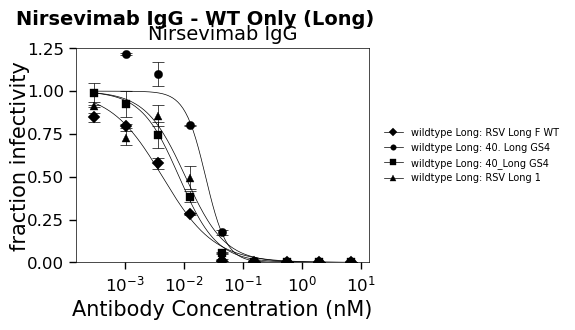

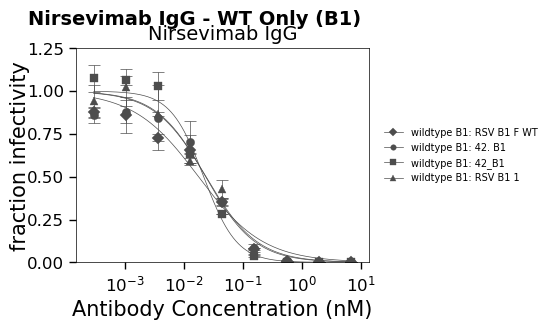

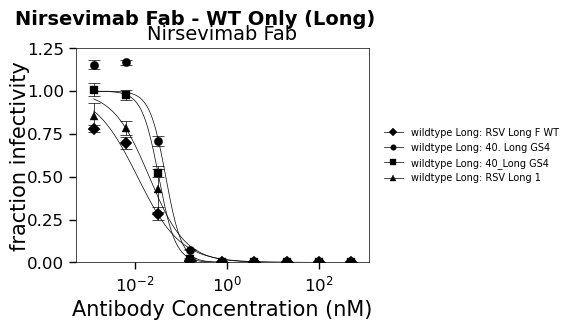

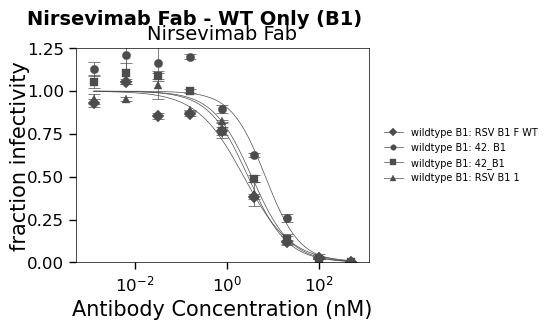

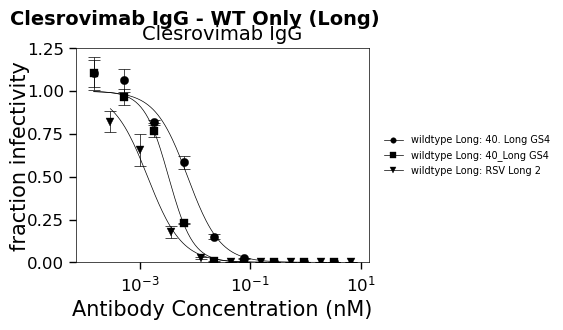

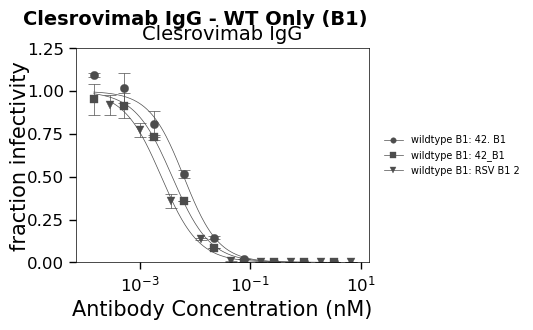

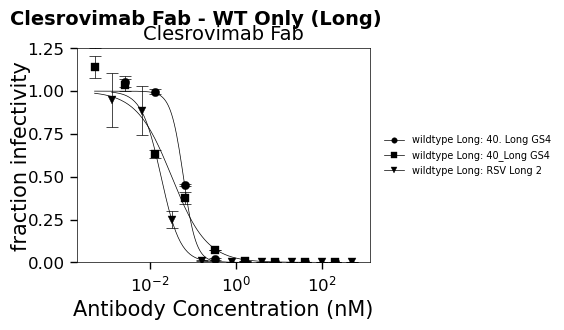

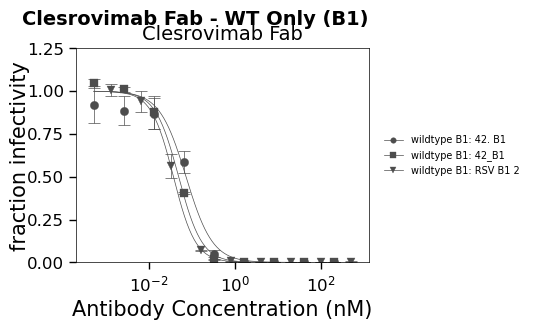

In [33]:
# Plot WT-only neutralization curves (separate plots by antibody, format, and background)
# Includes all WT variants for Long and B1 backgrounds

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# WT virus names for Long and B1 backgrounds
wt_long_viruses = [
    'RSV Long F WT ',
    '40. Long GS4',
    '40_Long GS4',
    'RSV Long 1',
    'RSV Long 2'
]

wt_b1_viruses = [
    'RSV B1 F WT',
    '42. B1',
    '42_B1',
    'RSV B1 1',
    'RSV B1 2'
]

wt_viruses = wt_long_viruses + wt_b1_viruses

# Pull WT data directly from combined_data to ensure all WT variants are included
df_wt = combined_data[combined_data['source_file'].isin(point_source_files)].copy()
df_wt = df_wt[~df_wt['serum'].str.contains('Suptavumab', na=False)]
df_wt = df_wt[df_wt['virus'].isin(wt_viruses)].copy()

# WT color/marker mapping (same colors as other WT, distinct markers per WT variant)
wt_color_marker = {
    # Long WT variants (black)
    '40. Long GS4': ('#000000', 'o'),
    '40_Long GS4': ('#000000', 's'),
    'RSV Long F WT ': ('#000000', 'D'),
    'RSV Long 1': ('#000000', '^'),
    'RSV Long 2': ('#000000', 'v'),

    # B1 WT variants (dark grey)
    '42. B1': ('#4d4d4d', 'o'),
    '42_B1': ('#4d4d4d', 's'),
    'RSV B1 F WT': ('#4d4d4d', 'D'),
    'RSV B1 1': ('#4d4d4d', '^'),
    'RSV B1 2': ('#4d4d4d', 'v'),
}

def build_wt_legend(ax, viruses):
    """Create a clean legend with WT-only entries and meaningful labels."""
    existing = ax.get_legend()
    if existing:
        existing.remove()
    # In case a second legend is attached
    if hasattr(ax, 'legend_') and ax.legend_ is not None:
        ax.legend_.remove()
    # Remove any figure-level legends
    fig = ax.figure
    for leg in getattr(fig, 'legends', []):
        leg.remove()

    handles = []
    labels = []

    for virus in viruses:
        if virus not in wt_color_marker:
            continue
        color, marker = wt_color_marker[virus]
        handles.append(
            Line2D([0], [0], color=color, marker=marker, linestyle='-', linewidth=0.5)
        )
        if virus in wt_long_viruses:
            labels.append(f"wildtype Long: {virus}")
        else:
            labels.append(f"wildtype B1: {virus}")

    ax.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=True, fontsize=7)
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_linewidth(0.5)

# Store original rcParams to restore later
original_rcParams_wt = mpl.rcParams.copy()

# Set matplotlib parameters for publication-ready figures
mpl.rcParams['svg.fonttype'] = 'none'  # Make text editable in SVG
mpl.rcParams['axes.linewidth'] = 0.5   # Box around plot
mpl.rcParams['xtick.major.width'] = 0.5  # X-axis tick width
mpl.rcParams['ytick.major.width'] = 0.5  # Y-axis tick width
mpl.rcParams['xtick.minor.width'] = 0.5  # X-axis minor tick width
mpl.rcParams['ytick.minor.width'] = 0.5  # Y-axis minor tick width
mpl.rcParams['lines.linewidth'] = 0.5    # Line width for curves
mpl.rcParams['lines.markersize'] = 4
mpl.rcParams['lines.markeredgecolor'] = 'auto'  # No marker stroke
mpl.rcParams['legend.edgecolor'] = 'none'  # No legend box stroke
mpl.rcParams['lines.markeredgewidth'] = 0.25  # No stroke around markers
     # Marker size

print("Generating WT-only plots (separate Long and B1 backgrounds)...")

antibodies = ['Nirsevimab', 'Clesrovimab']
formats = ['IgG', 'Fab']
backgrounds = [
    ('Long', wt_long_viruses),
    ('B1', wt_b1_viruses)
]

for antibody in antibodies:
    for fmt in formats:
        serum_name = f"{antibody} {fmt}"

        for background_label, wt_list in backgrounds:
            # Get WT viruses that have data for this serum
            serum_viruses = set(df_wt[df_wt['serum'] == serum_name]['virus'].unique())
            viruses_to_plot = [v for v in wt_list if v in serum_viruses]

            if len(viruses_to_plot) == 0:
                print(f"  Skipping {serum_name} {background_label} (no WT data)")
                continue

            print(f"  Plotting {serum_name} WT-only ({background_label}) ({len(viruses_to_plot)} viruses)")

            # Ensure mapping covers all WT viruses for this serum
            wt_mapping = {v: wt_color_marker[v] for v in viruses_to_plot if v in wt_color_marker}

            fits_wt = neutcurve.curvefits.CurveFits(
                data=df_wt,
                fixbottom=0,
                fixtop=1,
            )

            fig, axes = fits_wt.plotSera(
                xlabel='Antibody Concentration (nM)',
                sera=[serum_name],
                viruses=viruses_to_plot,
                virus_to_color_marker=wt_mapping,
                max_viruses_per_subplot=20,
                ncol=2,
                draw_in_bounds=True,
                legendfontsize=7
            )

            # Remove any existing legends (axes + figure) before custom WT legend
            for ax in (axes.flat if isinstance(axes, np.ndarray) else [axes]):
                if ax.get_legend() is not None:
                    ax.get_legend().remove()
            for leg in getattr(fig, 'legends', []):
                leg.remove()

            # Apply formatting to all axes
            if isinstance(axes, np.ndarray):
                axes_list = axes.flat
            else:
                axes_list = [axes]

            for ax in axes_list:
                ax.set_ylim(0, 1.25)

                if ax.get_legend() is not None:
                    ax.get_legend().remove()

                for line in ax.lines:
                    line.set_linewidth(0.5)
                    if line.get_marker() in ['_', '|']:
                        line.set_markeredgewidth(0.5)
                for collection in ax.collections:
                    collection.set_linewidth(0.5)

                # Replace default legend with custom WT legend
                build_wt_legend(ax, viruses_to_plot)

            fig.suptitle(
                f"{serum_name} - WT Only ({background_label})",
                y=1.001,
                fontsize=14,
                fontweight='bold'
            )

            #filename_pdf = f"03_output/plots/wt_only_{antibody}_{fmt}_{background_label}.pdf"
            #fig.savefig(filename_pdf, dpi=300, bbox_inches='tight')
            #print(f"    Saved: {filename_pdf}")

            fig.show()

mpl.rcParams.update(original_rcParams_wt)

print("\n✓ Completed WT-only plots")


In [34]:
# Extract all WT conditions for Long and B1 with dates and IC50 values for Nirsevimab IgG and Fab

# Define WT virus names for Long and B1 backgrounds
wt_viruses = [
    'RSV Long F WT ',
    '40. Long GS4',
    '40_Long GS4',
    'RSV Long 1',
    'RSV Long 2',
    'RSV B1 F WT',
    '42. B1',
    '42_B1',
    'RSV B1 1',
    'RSV B1 2'
]

# Filter params for WT viruses and Nirsevimab sera
wt_params = params[
    (params['virus'].isin(wt_viruses)) &
    (params['serum'].isin(['Nirsevimab IgG', 'Nirsevimab Fab']))
].copy()

# Get source file information from df for each virus
virus_to_source_date = {}
for virus in wt_viruses:
    virus_data = df[df['virus'] == virus]
    if len(virus_data) > 0:
        source_file = virus_data['source_file'].iloc[0]
        # Extract date from source file name
        if '250828' in source_file:
            date = '2025-08-28'
        elif '251002' in source_file:
            date = '2025-10-02'
        elif '251212' in source_file:
            date = '2025-12-12'
        elif '251217' in source_file:
            date = '2025-12-17'
        elif '2025.07.24' in source_file:
            date = '2025-07-24'
        else:
            date = 'Unknown'
        virus_to_source_date[virus] = {'source_file': source_file, 'date': date}

# Add date and source file information to the params
wt_params['date'] = wt_params['virus'].map(lambda v: virus_to_source_date.get(v, {}).get('date', 'Unknown'))
wt_params['source_file'] = wt_params['virus'].map(lambda v: virus_to_source_date.get(v, {}).get('source_file', 'Unknown'))

# Determine background (Long or B1) based on virus name
def determine_background(virus_name):
    if 'Long' in virus_name or '40.' in virus_name or '40_' in virus_name:
        return 'Long'
    elif 'B1' in virus_name or '42.' in virus_name or '42_' in virus_name:
        return 'B1'
    else:
        return 'Unknown'

wt_params['background'] = wt_params['virus'].apply(determine_background)

# Select and reorder columns for display
wt_summary = wt_params[[
    'background',
    'virus',
    'date',
    'serum',
    'ic50',
    'ic50_str',
    'ic50_bound',
    'source_file'
]].copy()

# Sort by background, date, and serum
wt_summary = wt_summary.sort_values(['background', 'date', 'serum'])

print(f"WT Controls Summary - Nirsevimab IgG and Fab IC50 Values")
print(f"Total entries: {len(wt_summary)}")
print(f"\nLong background controls: {len(wt_summary[wt_summary['background'] == 'Long'])}")
print(f"B1 background controls: {len(wt_summary[wt_summary['background'] == 'B1'])}")

display(wt_summary)



WT Controls Summary - Nirsevimab IgG and Fab IC50 Values
Total entries: 12

Long background controls: 6
B1 background controls: 6


,background,virus,date,serum,ic50,ic50_str,ic50_bound,source_file
57,B1,RSV B1 F WT,2025-10-02,Nirsevimab Fab,2.347670,2.35,interpolated,251002_fractinfect_molar.csv
26,B1,RSV B1 F WT,2025-10-02,Nirsevimab IgG,0.017585,0.0176,interpolated,251002_fractinfect_molar.csv
49,B1,42_B1,2025-12-12,Nirsevimab Fab,3.490619,3.49,interpolated,251212_fractinfect_molar.csv
18,B1,42_B1,2025-12-12,Nirsevimab IgG,0.021499,0.0215,interpolated,251212_fractinfect_molar.csv
58,B1,42. B1,2025-12-17,Nirsevimab Fab,6.929534,6.93,interpolated,251217_fractinfect_molar_pointmt.csv
27,B1,42. B1,2025-12-17,Nirsevimab IgG,0.023513,0.0235,interpolated,251217_fractinfect_molar_pointmt.csv
56,Long,RSV Long F WT,2025-08-28,Nirsevimab Fab,0.011467,0.0115,interpolated,250828_fractinfect.csv
25,Long,RSV Long F WT,2025-08-28,Nirsevimab IgG,0.004311,0.00431,interpolated,250828_fractinfect.csv
48,Long,40_Long GS4,2025-12-12,Nirsevimab Fab,0.033143,0.0331,interpolated,251212_fractinfect_molar.csv
17,Long,40_Long GS4,2025-12-12,Nirsevimab IgG,0.008235,0.00824,interpolated,251212_fractinfect_molar.csv
